**CSI 4106 Introduction to Artificial Intelligence** <br/>
*Assignment 3: Neural Networks*

# Identification

Name: Kien Do <br/>
Student Number: 300163370

Name: Kanjanokphat Kitisuwanakul <br/>
Student Number: 300170040

## 1. Exploratory Analysis

### Loading the dataset

A custom dataset has been created for this assignment. It has been made available on a public GitHub repository:

- [github.com/turcotte/csi4106-f24/tree/main/assignments-data/a3](https://github.com/turcotte/csi4106-f24/tree/main/assignments-data/a3)

Access and read the dataset directly from this GitHub repository in your Jupyter notebook.

You can use this code cell for you import statements and other initializations.

## Imports & Initial loading

In [ ]:
# imports
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

In [ ]:
test = pd.read_csv('https://raw.githubusercontent.com/turcotte/csi4106-f24/refs/heads/main/assignments-data/a3/cb513_test.csv')
train = pd.read_csv('https://raw.githubusercontent.com/turcotte/csi4106-f24/refs/heads/main/assignments-data/a3/cb513_train.csv')
valid = pd.read_csv('https://raw.githubusercontent.com/turcotte/csi4106-f24/refs/heads/main/assignments-data/a3/cb513_valid.csv')

### Data Pre-Processing

2. **Shuffling the Rows**:

    - Since examples are generated by sliding a window across each protein sequence, most adjacent examples originate from the same protein and share 20 positions. To mitigate the potential negative impact on model training, the initial step involves shuffling the **rows** of the data matrix.

In [ ]:
print(train.head())
# notice how the dataset does not have any column names

   2       0  0.0556     0.1  0.0556.1  0.1111     0.2  0.0556.2     0.3  \
0  2  0.0000     0.0  0.0000    0.0000     0.0  0.0000    0.0000  0.0000   
1  2  0.1905     0.0  0.3333    0.0000     0.0  0.0000    0.0000  0.0000   
2  2  0.0225     0.0  0.0112    0.1348     0.0  0.0112    0.1348  0.0112   
3  2  0.0000     0.0  0.0000    0.0000     0.0  0.0000    0.0000  0.0000   
4  0  0.0000     0.0  0.0000    0.0000     0.0  0.0000    0.0000  0.0000   

      0.4  ...  0.1667.17  0.2222.12   0.295   0.296  0.1667.18   0.297  \
0  0.0000  ...        0.0     0.0000  0.0000  0.0000     0.0000  0.0000   
1  0.2857  ...        0.0     0.0000  0.0000  0.0000     0.0000  0.0000   
2  0.1685  ...        0.0     0.0787  0.0674  0.0112     0.0225  0.1573   
3  0.0000  ...        0.0     0.0000  0.0000  0.6667     0.0000  0.0000   
4  0.3333  ...        0.0     0.0000  0.0000  0.0000     0.0000  0.0000   

   0.298   0.299  0.300  0.301  
0    0.0  0.0000  0.000    0.0  
1    0.0  0.1905  0.381   

In [ ]:
# add column / attribute names to the dataset

num_train_columns = train.shape[1] # number of columns

# create a list of column names
column_names = ["label"]
for i in range(1,num_train_columns):
    column_names.append(f"feature_{i}")

# assign column names to the dataframe
train.columns = column_names

print(train.head())

   label  feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0      2     0.0000        0.0     0.0000     0.0000        0.0     0.0000   
1      2     0.1905        0.0     0.3333     0.0000        0.0     0.0000   
2      2     0.0225        0.0     0.0112     0.1348        0.0     0.0112   
3      2     0.0000        0.0     0.0000     0.0000        0.0     0.0000   
4      0     0.0000        0.0     0.0000     0.0000        0.0     0.0000   

   feature_7  feature_8  feature_9  ...  feature_453  feature_454  \
0     0.0000     0.0000     0.0000  ...          0.0       0.0000   
1     0.0000     0.0000     0.2857  ...          0.0       0.0000   
2     0.1348     0.0112     0.1685  ...          0.0       0.0787   
3     0.0000     0.0000     0.0000  ...          0.0       0.0000   
4     0.0000     0.0000     0.3333  ...          0.0       0.0000   

   feature_455  feature_456  feature_457  feature_458  feature_459  \
0       0.0000       0.0000       0.0000      

In [ ]:
# do the same for the other 2 sets
valid.columns = column_names
test.columns = column_names

print(valid.head())

   label  feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0      0     0.0090      0.018     0.0360     0.0450     0.0000     0.0270   
1      2     0.0000      0.000     0.0000     0.0000     0.0000     0.0000   
2      2     0.6341      0.000     0.0000     0.0000     0.0488     0.0976   
3      2     0.0000      0.000     0.0000     0.0714     0.0000     0.0714   
4      0     0.1176      0.000     0.0294     0.0294     0.0588     0.0000   

   feature_7  feature_8  feature_9  ...  feature_453  feature_454  \
0     0.0991     0.0090     0.0090  ...       0.0270       0.0270   
1     0.0000     0.0000     0.6667  ...       0.0000       0.0000   
2     0.0000     0.0122     0.0122  ...       0.0488       0.1341   
3     0.0000     0.0714     0.1429  ...       0.0000       0.0714   
4     0.1765     0.0000     0.0000  ...       0.3235       0.0000   

   feature_455  feature_456  feature_457  feature_458  feature_459  \
0       0.0270       0.0180       0.0360      

In [ ]:
# shuffle the rows of training set in place
train = train.sample(frac=1).reset_index(drop=True)

In [ ]:
# view shuffled dataframe
print(train.head())

   label  feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0      2     0.0930        0.0     0.0349     0.0930     0.0116     0.0000   
1      2     0.0000        0.0     0.0000     0.0000     0.0000     0.0000   
2      0     0.0432        0.0     0.1189     0.0432     0.0108     0.0378   
3      0     0.0556        0.0     0.0000     0.0000     0.0556     0.5556   
4      1     0.0000        0.0     0.0000     0.0000     0.0000     0.0000   

   feature_7  feature_8  feature_9  ...  feature_453  feature_454  \
0     0.0116     0.0349     0.1163  ...          0.0       0.0116   
1     0.0000     0.1000     0.0000  ...          0.0       0.0000   
2     0.0000     0.0108     0.0432  ...          0.0       0.2649   
3     0.0000     0.0000     0.0000  ...          0.0       0.0000   
4     0.0000     0.0000     0.0000  ...          0.0       0.5000   

   feature_455  feature_456  feature_457  feature_458  feature_459  \
0       0.0581       0.0465       0.0349      

3. **Scaling of Numerical Features**:

    - Since all 462 features are proportions represented as values between 0 and 1, scaling may not be necessary. In our evaluations, using [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) actually degraded model performance. Within your pipeline, compare the effects of not scaling the data versus applying [MinMaxScaler](https://scikit-learn.org/1.5/modules/generated/sklearn.preprocessing.MinMaxScaler.html). In the interest of time, a single experiment will suffice. It is important to note that when scaling is applied, a uniform method should be used across all columns, given their homogeneous nature.

We will scale and display the histograms of the first 3 features in the dataset to compare the non-scaled and scaled data.

**Note for scaled vs unscaled data:**
- Please view the experiment of scaled vs unscaled data on the Decision Tree on **part 6 Model Evaluation**
- Please view the experiment of scaled vs unscaled data on the Neural Network on **part 9 Testing** at the very end.

In [ ]:
# fit transform the training set
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
train_scaled = pd.DataFrame(train_scaled, columns=train.columns)

In [ ]:
# transform validation and test data
valid_scaled = scaler.transform(valid)
test_scaled = scaler.transform(test)

# convert to dataframe
valid_scaled = pd.DataFrame(valid_scaled, columns=valid.columns)
test_scaled = pd.DataFrame(test_scaled, columns=test.columns)

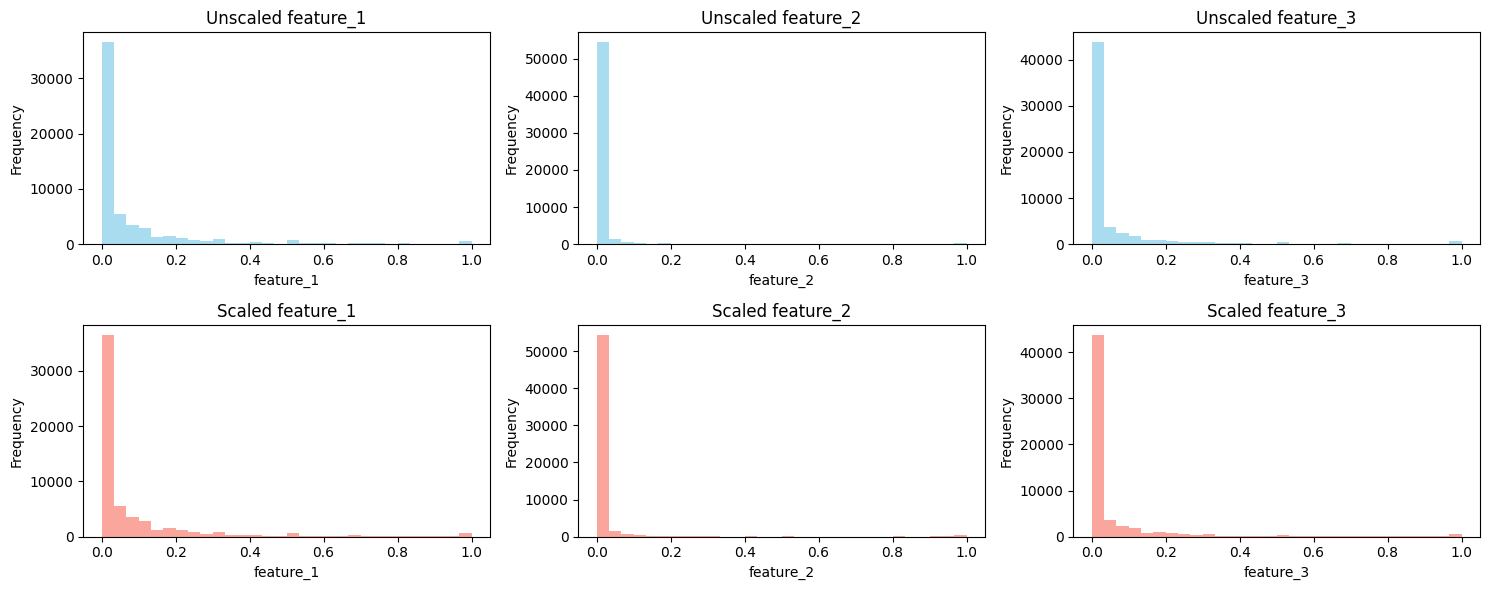

In [ ]:
# Select first 3 features to compare
features_to_plot = ['feature_1', 'feature_2', 'feature_3']

# Plot unscaled and scaled data
fig, axes = plt.subplots(nrows=2, ncols=len(features_to_plot), figsize=(15, 6))

# Plot unscaled data
for i, feature in enumerate(features_to_plot):
    axes[0, i].hist(train[feature], bins=30, color='skyblue', alpha=0.7)
    axes[0, i].set_title(f"Unscaled {feature}")
    axes[0, i].set_xlabel(feature)
    axes[0, i].set_ylabel("Frequency")

# Plot scaled data
for i, feature in enumerate(features_to_plot):
    axes[1, i].hist(train_scaled[feature], bins=30, color='salmon', alpha=0.7)
    axes[1, i].set_title(f"Scaled {feature}")
    axes[1, i].set_xlabel(feature)
    axes[1, i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

We can see that the non-scaled and scaled data are not that different from each other. As predicted, given that all 462 features are proportions represented as values between 0 and 1, applying MinMaxScaler does not result in noticeable differences.

We will make a more concrete comparison by training the baseline model with scaled and non-scaled data in the following section.

4. **Isolating the Target and the Data**:

    - In the CSV files, the target and data are combined. To prepare for our machine learning experiments, separate the training data $X$ and the target vector $y$ for each of the three datasets.

In [ ]:
# ========  REGULAR DATA  ========
X_train = train.drop('label', axis=1) # drop the label to get training data
y_train = train['label'] # drop the training data to get the label

X_valid = valid.drop('label', axis=1)
y_valid = valid['label']

X_test = test.drop('label', axis=1)
y_test = test['label']

# ========  SCALED DATA  ========
# Labels remain categorical in classification problems, so we
# do not need a "Y_train_scaled"
X_train_scaled = train_scaled.drop('label', axis=1)

X_valid_scaled = valid_scaled.drop('label', axis=1)

X_test_scaled = test_scaled.drop('label', axis=1)

## Model Development & Evaluation

### 5. Model Development




- **Dummy Model**: Implement a model utilizing the [DummyClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html). This model disregards the input data and predicts the majority class. Such model is sometimes called a straw man model.

- **Baseline Model**: As a baseline model, select one of the previously studied machine learning algorithms: Decision Trees, K-Nearest Neighbors (KNN), or Logistic Regression. Use the default parameters provided by scikit-learn to train each model as a baseline. Why did you choose this particular classifier? Why do you think it should be appropriate for this specific task?

- **Neural Network Model**: Utilizing [Keras](https://keras.io) and [TensorFlow](https://www.tensorflow.org), construct a sequential model comprising an input layer, a hidden layer, and an output layer. The input layer should consist of 462 nodes, reflecting the 462 attributes of each example. The hidden layer should include 8 nodes and employ the default activation function. The output layer should contain three nodes, corresponding to the three classes: helix (0), sheet (1), and coil (2). Apply the softmax activation function to the output layer to ensure that the outputs are treated as probabilities, with their sum equaling 1 for each training example.

We therefore have three models: dummy, baseline, and neural network.

The **Dummy Classifier** in scikit-learn doesn't “learn” from the data in the way typical classifiers (like decision trees or logistic regression) do. Instead, it follows simple strategies to make predictions, ignoring any patterns in the input features.

Some common strategies for the Dummy Classifier include:

1. **"most_frequent"**: Always predicts the most frequent class in the training data. For example, if 70% of the training data belongs to class 0, the Dummy Classifier will always predict class 0.

2. **"stratified"**: Generates predictions by respecting the class distribution in the training data. So if 70% of the training data is class 0 and 30% is class 1, it will make predictions in approximately the same ratio.

3. **"uniform"**: Makes random predictions with equal probability for each class.

4. **"constant"**: Always predicts a specified constant label, which you define.

The Dummy Classifier is useful for evaluating the performance of more complex models. If our model performs worse than the Dummy Classifier, it suggests that it may not be learning patterns in the data effectively.

In [ ]:
# Dummy model using "most_frequent" strategy

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)

DummyClassifier(strategy='most_frequent')

In [ ]:
# Baseline model - Decision Tree

# Limitations:
# - max_depth: limits the depth of the tree to prevent overfitting
# - min_samples_split: minimum number of samples required to split an internal node
# - min_samples_leaf: minimum number of samples required to be at a leaf node

# Train the model on both scaled and non-scaled data for one final
# comparison between using scaled and non-scaled data

# Regular data
clf = DecisionTreeClassifier(max_depth=10, min_samples_split=5, min_samples_leaf=2, random_state=42)
clf.fit(X_train, y_train)

# Scaled data
clf_scaled = DecisionTreeClassifier(max_depth=10, min_samples_split=5, min_samples_leaf=2, random_state=42)
clf_scaled.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       random_state=42)

In [ ]:
# NN Model
# Define the model's architecture. Data will be fed into this model later during the training phase

# choose sequential model
NN_model = tf.keras.Sequential()

# The input layer should consist of 462 nodes, reflecting the 462 attributes of each example.
NN_model.add(tf.keras.layers.InputLayer(shape=(462,)))

# The hidden layer should include 8 nodes and employ the default activation function.
NN_model.add(tf.keras.layers.Dense(8, activation='relu'))

# The output layer should contain three nodes, corresponding to the three classes:
NN_model.add(tf.keras.layers.Dense(3, activation='softmax'))

NN_model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                     │ (None, 8)                   │           3,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,731 (14.57 KB)

 Trainable params: 3,731 (14.57 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compile the Neural network model
NN_model.compile(optimizer='sgd',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

### 6. Model Evaluation:

- Employ cross-validation to assess the performance of the baseline model. Select a small number of folds to prevent excessive computational demands.

In [ ]:
# Cross validation for the baseline model

# NOTE: In cross validation, only use training set (e.g. X_train, y_train)

# Calculate the precision, use Macro as this is a multiclass problem
precision_dt = cross_val_score(clf, X_train, y_train, cv=5, scoring='precision_macro')
print("Precision Scores               :", precision_dt)
print("Mean precision                 :", precision_dt.mean())

print()

precision_dt_scaled = cross_val_score(clf_scaled, X_train_scaled, y_train, cv=5, scoring='precision_macro')
print("Precision Scores (scaled data) :", precision_dt_scaled)
print("Mean precision (scaled data)   :", precision_dt_scaled.mean())

Precision Scores               : [0.5254489  0.54246617 0.53146037 0.53456132 0.52813119]
Mean precision                 : 0.5324135883090805

Precision Scores (scaled data) : [0.5254489  0.54246617 0.53146037 0.53456132 0.52813119]
Mean precision (scaled data)   : 0.5324135883090805


In [ ]:
# Calculate f1 score of logistic model
f1_dt = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')
print("F1 Scores          : ", f1_dt)
print("Mean F1            : ", f1_dt.mean())

print()

f1_dt_scaled = cross_val_score(clf_scaled, X_train_scaled, y_train, cv=5, scoring='f1_macro')
print("F1 Scores (scaled) : ", f1_dt_scaled)
print("Mean F1 (scaled)   : ", f1_dt_scaled.mean())

F1 Scores          :  [0.498491   0.52048565 0.51386686 0.5157635  0.51110768]
Mean F1            :  0.5119429368903251

F1 Scores (scaled) :  [0.498491   0.52048565 0.51386686 0.5157635  0.51110768]
Mean F1 (scaled)   :  0.5119429368903251


In [ ]:
# Calculate the recall of the logistic model
recall_dt = cross_val_score(clf, X_train, y_train, cv=5, scoring='recall_macro')
print("Precision Scores          :", recall_dt)
print("Mean precision            :", recall_dt.mean())

print()

recall_dt_scaled = cross_val_score(clf_scaled, X_train_scaled, y_train, cv=5, scoring='recall_macro')
print("Precision Scores (scaled) :", recall_dt_scaled)
print("Mean precision (scaled)   :", recall_dt_scaled.mean())

Precision Scores          : [0.50211037 0.51978025 0.51242847 0.5156421  0.51012879]
Mean precision            : 0.5120179953102946

Precision Scores (scaled) : [0.50211037 0.51978025 0.51242847 0.5156421  0.51012879]
Mean precision (scaled)   : 0.5120179953102946


**Scaled vs Unscaled data**

Here, we once again compare the difference between scaled and non-scaled data, by training the baseline model (decision tree) on scaled and non-scaled data.

Based on the results above, we can conclude that the precision, F1, and recall of the non-scaled and scaled data used to train the baseline model are identical. As such, we can proceed using only non-scaled data for the rest of this assignment.

**Training neural networks can be time-consuming.** Consequently, their performance is typically assessed once using a validation set. Make sure to not use the test set until the very end of the assignment.

In [ ]:
# Train the neural network model
history = NN_model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

Epoch 1/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4324 - loss: 1.0621 - val_accuracy: 0.5477 - val_loss: 0.9761
Epoch 2/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5872 - loss: 0.9132 - val_accuracy: 0.6308 - val_loss: 0.8520
Epoch 3/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6598 - loss: 0.8052 - val_accuracy: 0.6598 - val_loss: 0.8020
Epoch 4/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6804 - loss: 0.7627 - val_accuracy: 0.6690 - val_loss: 0.7795
Epoch 5/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6912 - loss: 0.7428 - val_accuracy: 0.6737 - val_loss: 0.7752
Epoch 6/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6930 - loss: 0.7298 - val_accuracy: 0.6756 - val_loss: 0.7712
Epoch 7/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6922 - loss: 0.7347 - val_accuracy: 0.6667 - val_loss: 0.7741
Epoch 8/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6941 - loss: 0.7281 - 

 Assess the models using metrics such as precision, recall, and F1-score.


In [ ]:
# visualization
y_proba = NN_model.predict(X_valid) # Use model to predict probabilities of each class being [0,1,2] in X_valid
y_pred = y_proba.argmax(axis=-1) # Convert model probability prediction into class labels

print(classification_report(y_valid, y_pred)) # Generate report of real vs predicted labels

232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.70      0.68      0.69      2490
           1       0.66      0.47      0.55      1808
           2       0.67      0.79      0.72      3110

    accuracy                           0.68      7408
   macro avg       0.68      0.65      0.65      7408
weighted avg       0.68      0.68      0.67      7408




## Hyperparameter Optimization: Baseline Model


### 7. Baseline Model:

- To ensure a fair comparison for our baseline model, we will examine how varying hyperparameter values affect its performance. This prevents the erroneous conclusion that neural networks inherently perform better, when in fact, appropriate hyperparameter tuning could enhance the baseline model's performance.

- Focus on the following relevant hyperparameters for each model:

  - [DecisionTreeClassifier](https://scikit-learn.org/dev/modules/generated/sklearn.tree.DecisionTreeClassifier.html): `criterion` and `max_depth`.
  
  - [LogisticRegression](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html): `penalty`, `max_iter`, and `tol`.
  
  - [KNeighborsClassifier](https://scikit-learn.org/dev/modules/generated/sklearn.neighbors.KNeighborsClassifier.html): `n_neighbors` and `weights`.

- Employ a grid search strategy or utilize scikit-learn's built-in methods [GridSearchCV](https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.GridSearchCV.html) to thoroughly evaluate all combinations of hyperparameter values. Cross-validation should be used to assess each combination.

- Quantify the performance of each hyperparameter configuration using precision, recall, and F1-score as metrics.

- Analyze the findings and offer insights into which hyperparameter configurations achieved optimal performance for each model.

In [ ]:
# Decision Tree - Use the grid search strategy to find out which of the
# following hyperparameters values are the best, and will subsequently
# be used for the model

param_grid_dt = {
    'criterion': ['gini', 'entropy'],  # Two possible criteria
    'max_depth': range(1,10)  # Different tree depths to try
}

In [ ]:
# Baseline Model
# Exhaustively tests all combinations of hyperparameter values to find the best one

grid_search_dt = GridSearchCV(clf, param_grid_dt, cv=5, scoring='f1_macro')
grid_search_dt.fit(X_train, y_train)

grid_search_precision = GridSearchCV(clf, param_grid_dt, cv=5, scoring='precision_macro')
grid_search_precision.fit(X_train, y_train)

grid_search_recall = GridSearchCV(clf, param_grid_dt, cv=5, scoring='recall_macro')
grid_search_recall.fit(X_train, y_train)

print("Best params for Decision Tree:", grid_search_dt.best_params_)

print("Best precision:", grid_search_precision.best_score_) #best precision
print("Best recall:", grid_search_recall.best_score_) #best recall
print("Best F1:", grid_search_dt.best_score_) #best f1


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisi

Best params for Decision Tree: {'criterion': 'entropy', 'max_depth': 9}
Best precision: 0.5458497495719496
Best recall: 0.5197280581746677
Best F1: 0.5195560009153531


In [ ]:
# Visualize how metrics vary with the combinations of params

# Add to dataframe all metrics for all parameter combinations
df_f1 = pd.DataFrame(grid_search_dt.cv_results_)
df_precision = pd.DataFrame(grid_search_precision.cv_results_)
df_recall = pd.DataFrame(grid_search_recall.cv_results_)

# Build dataframe containing parameter combinations and the mean score for each metric
summary_df = pd.DataFrame({
    'params': df_f1['params'],
    'mean_test_f1': df_f1['mean_test_score'],
    'mean_test_precision': df_precision['mean_test_score'],
    'mean_test_recall': df_recall['mean_test_score']
})

print(summary_df)

                                      params  mean_test_f1  \
0      {'criterion': 'gini', 'max_depth': 1}      0.306512   
1      {'criterion': 'gini', 'max_depth': 2}      0.355153   
2      {'criterion': 'gini', 'max_depth': 3}      0.380708   
3      {'criterion': 'gini', 'max_depth': 4}      0.381975   
4      {'criterion': 'gini', 'max_depth': 5}      0.475037   
5      {'criterion': 'gini', 'max_depth': 6}      0.481467   
6      {'criterion': 'gini', 'max_depth': 7}      0.487526   
7      {'criterion': 'gini', 'max_depth': 8}      0.509266   
8      {'criterion': 'gini', 'max_depth': 9}      0.515131   
9   {'criterion': 'entropy', 'max_depth': 1}      0.306512   
10  {'criterion': 'entropy', 'max_depth': 2}      0.365446   
11  {'criterion': 'entropy', 'max_depth': 3}      0.422331   
12  {'criterion': 'entropy', 'max_depth': 4}      0.459839   
13  {'criterion': 'entropy', 'max_depth': 5}      0.481587   
14  {'criterion': 'entropy', 'max_depth': 6}      0.501619   
15  {'cr

In [ ]:
# Evaluate the results by observing the best hyperparameters and
# performance for the baseline model

print("Best parameters for Decision Tree:", grid_search_dt.best_params_)
print("Best score for Decision Tree:", grid_search_dt.best_score_)

Best parameters for Decision Tree: {'criterion': 'entropy', 'max_depth': 9}
Best score for Decision Tree: 0.5195560009153531


**Analysis**

Increasing `max_depth` significantly improved performance, as deeper trees can capture more complex patterns.
The best-performing configuration used is `max_depth=9`, suggesting that a balance between depth and generalization was achieved here.
The criterion `entropy` allowed for the best performance.

We determine that the best hyperparameters, measured by their F1 scores, is `entropy`, and max_depth of 9.

## Hyperparameter Optimization: Neural Network

8. **Neural Network:**

    In our exploration and tuning of neural networks, we focus on the following hyperparameters:

    - **Single hidden layer, varying the number of nodes**.

        - Start with a single node in the hidden layer. Use a graph to depict the progression of loss and accuracy for both the training and validation sets, with the horizontal axis representing the number of training epochs and the vertical axis showing loss and accuracy. Training this network should be relatively fast, so let's conduct training for 50 epochs. Observing the graph, what do you conclude? Is the network underfitting or overfitting? Why?

        - Repeat the above process using 2 and 4 nodes in the hidden layer. Use the same type of graph to document your observations regarding loss and accuracy.

        - Start with 8 nodes in the hidden layer and progressively double the number of nodes until it surpasses the number of nodes in the input layer. This results in seven experiments and corresponding graphs for the following configurations: 8, 16, 32, 64, 128, 256, and 512 nodes. Document your observations throughout the process.
        
        - Ensure that the **number of training epochs** is adequate for **observing an increase in validation loss**. **Tip**: During model development, start with a small number of epochs, such as 5 or 10. Once the model appears to perform well, test with larger values, like 40 or 80 epochs, which proved reasonable in our tests. Based on your observations, consider conducting further experiments, if needed. How many epochs were ultimately necessary?

### **Helper functions**

In [ ]:
# Lecture Introduction to Artificial Neural Networks
# slide 60,61

def varyNode(node):
  """
  Creates and compiles a neural network model with a custom number of hidden nodes
  and 1 hidden layer
  """
  NN_model = tf.keras.Sequential()
  NN_model.add(tf.keras.layers.InputLayer(shape=(462,)))
  NN_model.add(tf.keras.layers.Dense(node, activation='relu'))
  NN_model.add(tf.keras.layers.Dense(3, activation='softmax'))

  NN_model.compile(optimizer='sgd',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

  return NN_model

In [ ]:
# Create a function to train a model with a custom amount of layers and nodes
def varyLayers(nodes, layers):
    """
    Creates and compiles a neural network model with a custom number of hidden layers and nodes
    1 layer only adds a single hidden layer for example
    """
    NN_model = tf.keras.Sequential()
    NN_model.add(tf.keras.layers.InputLayer(shape=(462,))) # add the input layer

    # add the hidden layers
    for i in range(layers):
        NN_model.add(tf.keras.layers.Dense(nodes, activation='relu'))

    # add the output layer
    NN_model.add(tf.keras.layers.Dense(3, activation='softmax'))

    NN_model.compile(optimizer='sgd',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

    return NN_model


In [ ]:
# Create a function to train a model with a custom amount of layers and nodes
# add custom activation
def varyActivation(nodes, layers, my_activation):
    """
    Creates and compiles a neural network model with a custom number of hidden layers and nodes
    1 layer only adds a single hidden layer for example
    Adds customization for activation function
    """
    NN_model = tf.keras.Sequential()
    NN_model.add(tf.keras.layers.InputLayer(shape=(462,))) # add the input layer

    # add the hidden layers
    for i in range(layers):
        NN_model.add(tf.keras.layers.Dense(nodes, activation=my_activation))

    # add the output layer
    NN_model.add(tf.keras.layers.Dense(3, activation='softmax'))

    NN_model.compile(optimizer='sgd',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

    return NN_model

In [ ]:
def trainModel(model, my_epochs):
  """
  Trains the model with a custom number of epochs
  """
  history = model.fit(X_train, y_train, epochs=my_epochs, validation_data=(X_valid, y_valid))

  return history

In [ ]:
def plotGraph(my_history):
  """
  Plots the graph of loss and accuracy for the training and validation sets
  """
  pd.DataFrame(my_history.history).plot(
    figsize=(8, 5),
    grid=True,
    xlabel="Epochs",
    ylabel="Loss",
    style=["r--", "r--.", "b-", "b-*"]
  )
  plt.show()

In [ ]:
# create a new plot function to facilitate plotting
def plotAllGraphs(history_list):
    """
    Plots several loss and accuracy graphs for all training histories
    """

    # Number of subplots
    num_plots = len(history_list)
    cols = 4  # 4 plots per row to save space
    rows = int(np.ceil(num_plots / cols))  # Calculate rows needed for the given number of plots

    # Create a grid of subplots with a compact size
    fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 6))

    # Flatten the axes array to make indexing easier
    axes = axes.flatten()
    for i, history in enumerate(history_list):

        # Plot Loss and Accuracy on one graph
        df_history = pd.DataFrame(history.history)

        # Plot the data on the correct subplot (axis)
        df_history.plot(
            ax=axes[i],  # plot on the ith axis
            grid=True,
            xlabel="Epochs",
            ylabel="Value",
            style=["r--", "r--.", "b-", "b-*"]
        )

        # Add title for each model configuration
        axes[i].set_title(f"Model with {history.nodes} nodes")
        axes[i].set_ylabel("Loss/Accuracy")

    plt.tight_layout()  # Adjust layout for better spacing
    plt.show()

### Single hidden layer, varying the number of nodes

**Start with a single node in the hidden layer.**

In [ ]:
# Start with a single node in the hidden layer.
my_model = varyNode(1)

# Training this network should be relatively fast, so let's conduct training for 50 epochs
history = trainModel(my_model, 50)

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4022 - loss: 1.0783 - val_accuracy: 0.4239 - val_loss: 1.0770
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4296 - loss: 1.0616 - val_accuracy: 0.5269 - val_loss: 1.0285
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5673 - loss: 0.9874 - val_accuracy: 0.5829 - val_loss: 0.9471
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6109 - loss: 0.9089 - val_accuracy: 0.5938 - val_loss: 0.9086
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6179 - loss: 0.8794 - val_accuracy: 0.5910 - val_loss: 0.8973
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6200 - loss: 0.8687 - val_accuracy: 0.5950 - val_loss: 0.8907
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6198 - loss: 0.8690 - val_accuracy: 0.5910 - val_loss: 0.8905
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6204 - loss: 0.8608 - 

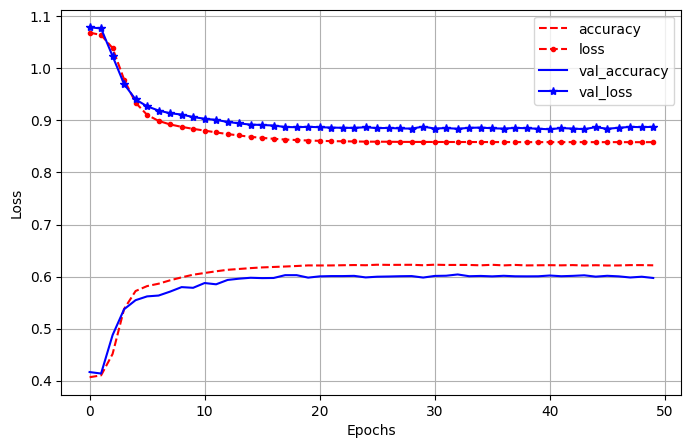

In [ ]:
# Use a graph to depict the progression of loss and accuracy for the training set and validation set
plotGraph(history)

Observing the graph, what do you conclude? Is the network underfitting or overfitting? Why?

The red lines represent **training data** while the blue lines represent the **validation data**.
We can see that:
- **loss & val_loss**: They both decrease from 1.09 to 9,9 and start plateauing at around 0.88. The loss of the training and validation set are quite close to one another. This indicates that the model has minimum error on both seen and unseen data.
- **accuracy and val_accuracy**: We can see an increase in accuracy from 0.4 to around 0.55 where both graphs start plateauing on 0.6. This means that the model is performing consistently on both validation and training sets.

This graph tells us that the model is generalizing well to unseen data as the training and validation accuracy and loss are close to each other.
There is a very small gap between training and validation accuracy or loss, this means that the network is **not overfitting.**

The accuracy is not too low and the loss is not too high either indicating that the model is also **not underfitting**.

**Using 2 nodes in the hidden layer**

Epoch 1/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.4744 - loss: 1.0504 - val_accuracy: 0.5667 - val_loss: 0.9673
Epoch 2/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5982 - loss: 0.9232 - val_accuracy: 0.5985 - val_loss: 0.9080
Epoch 3/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6130 - loss: 0.8792 - val_accuracy: 0.5949 - val_loss: 0.8941
Epoch 4/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6203 - loss: 0.8673 - val_accuracy: 0.5933 - val_loss: 0.8911
Epoch 5/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6230 - loss: 0.8603 - val_accuracy: 0.5967 - val_loss: 0.8861
Epoch 6/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6211 - loss: 0.8518 - val_accuracy: 0.5992 - val_loss: 0.8767
Epoch 7/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6240 - loss: 0.8455 - val_accuracy: 0.6187 - val_loss: 0.8538
Epoch 8/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6439 - loss: 0.8222 - 

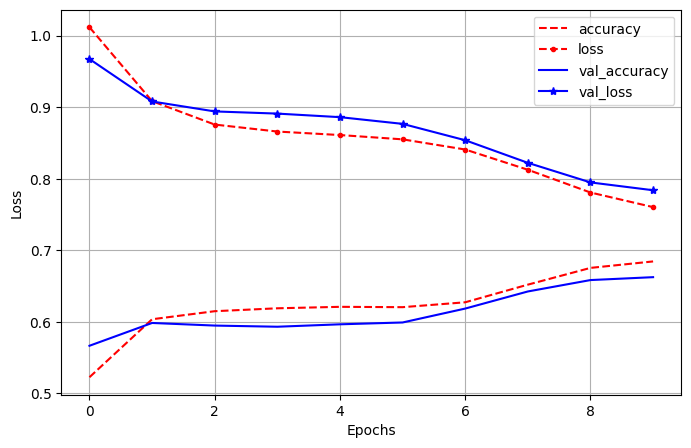

In [ ]:
# Repeat the above process using 2 nodes in the hidden layer
# start with 10 epochs
model2 = varyNode(2)
history2 = trainModel(model2, 10)
plotGraph(history2)

Epoch 1/20
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4131 - loss: 1.0712 - val_accuracy: 0.5059 - val_loss: 1.0287
Epoch 2/20
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5399 - loss: 0.9927 - val_accuracy: 0.5657 - val_loss: 0.9458
Epoch 3/20
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5894 - loss: 0.9093 - val_accuracy: 0.5872 - val_loss: 0.8827
Epoch 4/20
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6272 - loss: 0.8460 - val_accuracy: 0.6457 - val_loss: 0.8205
Epoch 5/20
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6732 - loss: 0.7807 - val_accuracy: 0.6664 - val_loss: 0.7872
Epoch 6/20
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6867 - loss: 0.7525 - val_accuracy: 0.6702 - val_loss: 0.7752
Epoch 7/20
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6896 - loss: 0.7431 - val_accuracy: 0.6666 - val_loss: 0.7751
Epoch 8/20
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6896 - loss: 0.7403 - 

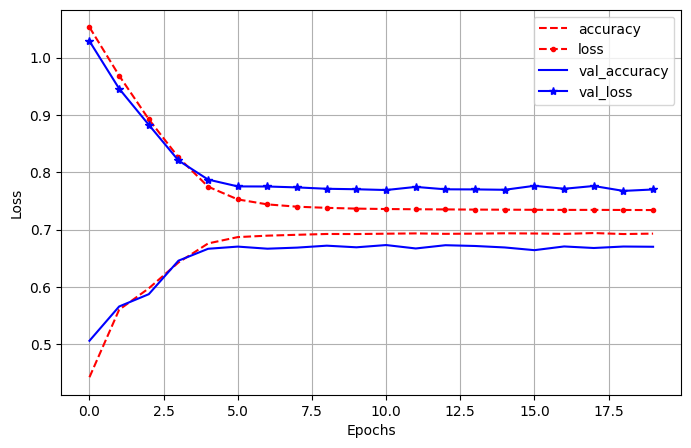

In [ ]:
# Try with more epochs as 10 did not plateau fully
model2 = varyNode(2)
history2 = trainModel(model2, 20)
plotGraph(history2)

**Observation**: 10 epochs were not sufficient to see the full trend of the graphs, but it seems that **20** epochs are sufficient to observe a plateau that converges.

With 2 nodes, the training accuracy and loss both seem to have improved by around 0.1.

Adding more nodes allows the model to have more parameters to learn from the data and to capture more complex patterns, yielding better results.

**Using 4 nodes in the hidden layer**

Epoch 1/15
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4533 - loss: 1.0564 - val_accuracy: 0.5517 - val_loss: 0.9999
Epoch 2/15
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5850 - loss: 0.9478 - val_accuracy: 0.6018 - val_loss: 0.8950
Epoch 3/15
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6411 - loss: 0.8425 - val_accuracy: 0.6506 - val_loss: 0.8179
Epoch 4/15
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6773 - loss: 0.7771 - val_accuracy: 0.6632 - val_loss: 0.7878
Epoch 5/15
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6866 - loss: 0.7512 - val_accuracy: 0.6720 - val_loss: 0.7776
Epoch 6/15
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6937 - loss: 0.7367 - val_accuracy: 0.6720 - val_loss: 0.7745
Epoch 7/15
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.6886 - loss: 0.7396 - val_accuracy: 0.6714 - val_loss: 0.7727
Epoch 8/15
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6939 - loss: 0.7344 - 

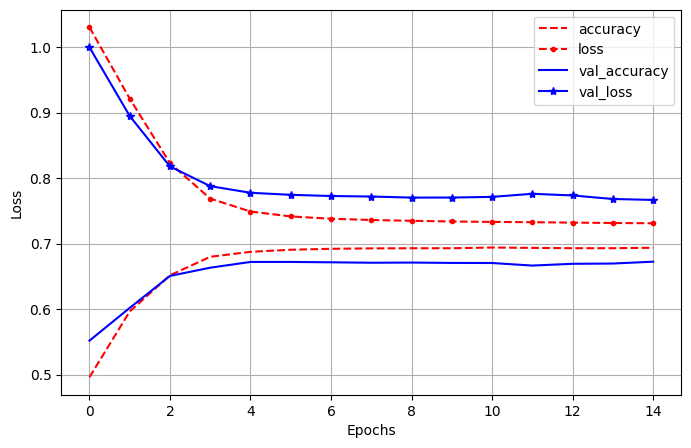

In [ ]:
# Repeat the above process using 4 nodes in the hidden layer
# Try with 15 epochs

model4 = varyNode(4)
history4 = trainModel(model4, 15)
plotGraph(history4)

**Observation**: With 15 epochs, we were also able to see the trend of the data properly plateau-ing.

There does not seem to be any significant change in the loss or accuracy with 4 nodes, as compared to using 2 nodes.

**With 8, 16, 32, 64, 128, 256, and 512 nodes**


Training model with 8 nodes...
Epoch 1/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4506 - loss: 1.0510 - val_accuracy: 0.5543 - val_loss: 0.9663
Epoch 2/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5951 - loss: 0.9057 - val_accuracy: 0.6363 - val_loss: 0.8397
Epoch 3/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6651 - loss: 0.7946 - val_accuracy: 0.6652 - val_loss: 0.7913
Epoch 4/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6808 - loss: 0.7579 - val_accuracy: 0.6633 - val_loss: 0.7795
Epoch 5/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6895 - loss: 0.7405 - val_accuracy: 0.6587 - val_loss: 0.7783
Epoch 6/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6901 - loss: 0.7383 - val_accuracy: 0.6708 - val_loss: 0.7705
Epoch 7/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6915 - loss: 0.7370 - val_accuracy: 0.6700 - val_loss: 0.7681
Epoch 8/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - a

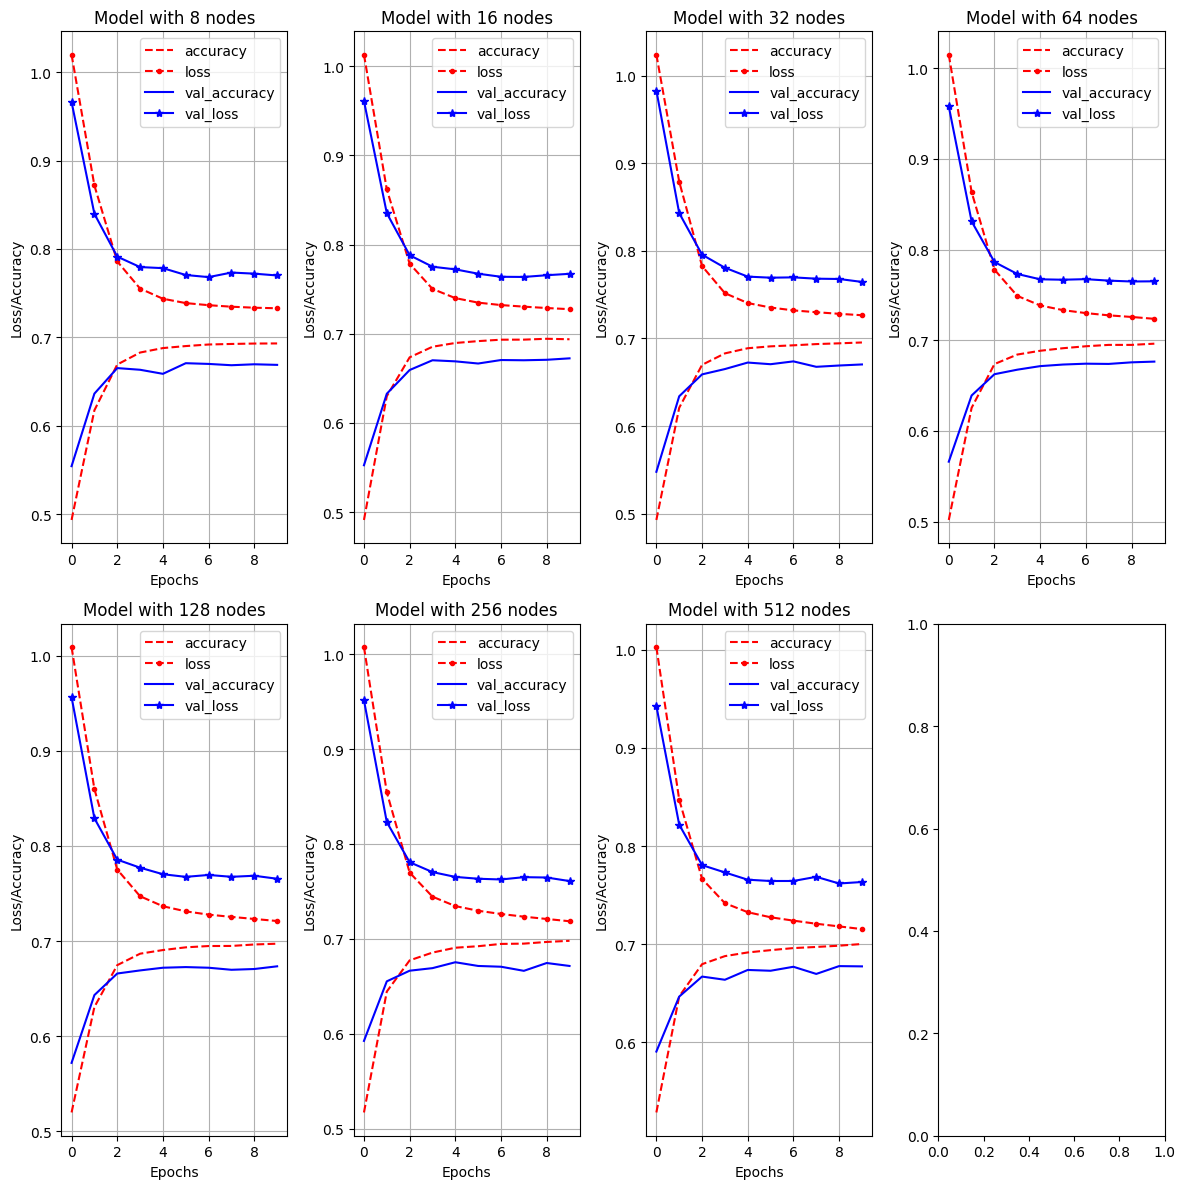

In [ ]:
# Train with 8, 16, 32, 64, 128, 256, and 512 nodes
history_list = []
for node in [8, 16, 32, 64, 128, 256, 512]:
    print(f"\nTraining model with {node} nodes...")
    model = varyNode(node)
    history = trainModel(model, 10) # 10 for faster training
    history.nodes = node
    history_list.append(history)

plotAllGraphs(history_list)


**Observations**:
 5 epochs do not show the full trend of the data.
 10 epochs is a good balance as more epochs will be very slow and consumes too many resources.

 We can observe a **gradual increase in accuracy and decrease in lost from nodes 8 to 32.** With a 64 nodes, we start seeing signs of **overfitting**.
 This is because increasing the number of nodes makes the model learn the exact data instead of the patterns. As the number of nodes grow too large, the model overfits the training data, and does poorly on validation.

 The loss of the validation set starts diverging more from the loss of the training set. A lower loss on the training set and higher loss on the validation set means that the model is doing well on seen data but very bad on onseen data (overfitting).

 Based on the experiments, we can conclude that **32** nodes is the right amount for this model to neither overfit nor underfit.



### Varying number of layers


- Conduct similar experiments as described above, but this time vary the number of layers from 1 to 4. Document your findings.

- How many nodes should each layer contain? Test at least two scenarios. Traditionally, a common strategy involved decreasing the number of nodes from the input layer to the output layer, often by halving, to create a pyramid-like structure. However, recent experience suggests that maintaining a constant number of nodes across all layers can perform equally well. Describe your observations. It is acceptable if both strategies yield similar performance results.

- Select one your models that exemplifies overfitting. In our experiments, we easily constructed a model achieving nearly 100% accuracy on the training data, yet showing no similar improvement on the validation set. Present this neural network along with its accuracy and loss graphs. Explain the reasoning for concluding that the model is overfitting.

**Varying layers 1-4 with 8 nodes**


Training model with 1 layer...
Epoch 1/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.4058 - loss: 1.0686 - val_accuracy: 0.4961 - val_loss: 1.0285
Epoch 2/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5400 - loss: 0.9775 - val_accuracy: 0.5865 - val_loss: 0.9102
Epoch 3/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6258 - loss: 0.8588 - val_accuracy: 0.6384 - val_loss: 0.8232
Epoch 4/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6670 - loss: 0.7850 - val_accuracy: 0.6586 - val_loss: 0.7878
Epoch 5/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6831 - loss: 0.7527 - val_accuracy: 0.6587 - val_loss: 0.7776
Epoch 6/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6929 - loss: 0.7358 - val_accuracy: 0.6737 - val_loss: 0.7705
Epoch 7/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6898 - loss: 0.7397 - val_accuracy: 0.6735 - val_loss: 0.7681
Epoch 8/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - ac

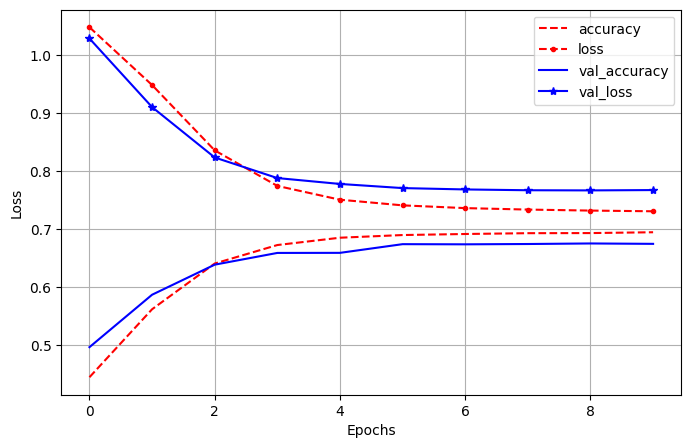

In [ ]:
# Train 4 models with layers 1 to 4 and 8 nodes

# For layer 1
print(f"\nTraining model with 1 layer...")
model = varyLayers(8, 1)
history = trainModel(model, 10) # 10 epochs is sufficient and for faster training
history.nodes = 8
print("---- 1 LAYER ---- ")
plotGraph(history)


Training model with 2 layers...
Epoch 1/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4020 - loss: 1.0718 - val_accuracy: 0.4436 - val_loss: 1.0629
Epoch 2/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4738 - loss: 1.0336 - val_accuracy: 0.5304 - val_loss: 0.9842
Epoch 3/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5882 - loss: 0.9194 - val_accuracy: 0.6454 - val_loss: 0.8300
Epoch 4/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6678 - loss: 0.7864 - val_accuracy: 0.6686 - val_loss: 0.7802
Epoch 5/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6850 - loss: 0.7460 - val_accuracy: 0.6698 - val_loss: 0.7716
Epoch 6/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.6910 - loss: 0.7376 - val_accuracy: 0.6704 - val_loss: 0.7696
Epoch 7/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6922 - loss: 0.7316 - val_accuracy: 0.6708 - val_loss: 0.7662
Epoch 8/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - 

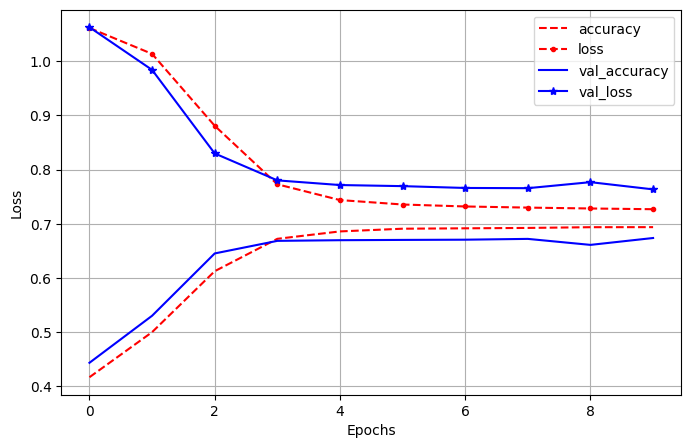

In [ ]:
# For layer 2
print(f"\nTraining model with 2 layers...")
model = varyLayers(8, 2)
history = trainModel(model, 10) # 10 is sufficient and for faster training
history.nodes = 8
print("---- 2 LAYERS ---- ")
plotGraph(history)


Training model with 3 layers...
Epoch 1/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.4042 - loss: 1.0715 - val_accuracy: 0.4726 - val_loss: 1.0617
Epoch 2/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5237 - loss: 1.0174 - val_accuracy: 0.5741 - val_loss: 0.9233
Epoch 3/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6083 - loss: 0.8791 - val_accuracy: 0.5967 - val_loss: 0.8726
Epoch 4/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6203 - loss: 0.8333 - val_accuracy: 0.6505 - val_loss: 0.8073
Epoch 5/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6760 - loss: 0.7650 - val_accuracy: 0.6635 - val_loss: 0.7786
Epoch 6/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6916 - loss: 0.7377 - val_accuracy: 0.6556 - val_loss: 0.7849
Epoch 7/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6950 - loss: 0.7266 - val_accuracy: 0.6664 - val_loss: 0.7821
Epoch 8/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - a

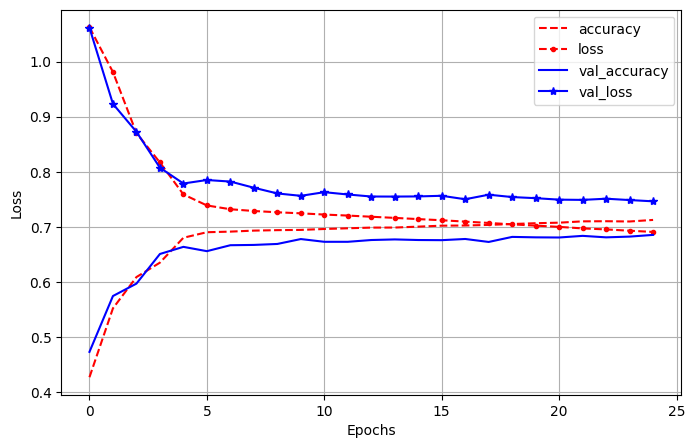

In [ ]:
# For layers 3
print(f"\nTraining model with 3 layers...")
model = varyLayers(8, 3)
history = trainModel(model, 25) # More epochs to see converge
history.nodes = 8
print("---- 3 LAYERS ---- ")
plotGraph(history)


Training model with 4 layers...
Epoch 1/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4111 - loss: 1.0659 - val_accuracy: 0.4442 - val_loss: 1.0600
Epoch 2/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4865 - loss: 1.0155 - val_accuracy: 0.6253 - val_loss: 0.8590
Epoch 3/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6643 - loss: 0.7953 - val_accuracy: 0.6727 - val_loss: 0.7819
Epoch 4/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6856 - loss: 0.7477 - val_accuracy: 0.6764 - val_loss: 0.7741
Epoch 5/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6906 - loss: 0.7364 - val_accuracy: 0.6763 - val_loss: 0.7716
Epoch 6/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6930 - loss: 0.7333 - val_accuracy: 0.6776 - val_loss: 0.7735
Epoch 7/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6946 - loss: 0.7281 - val_accuracy: 0.6729 - val_loss: 0.7690
Epoch 8/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - a

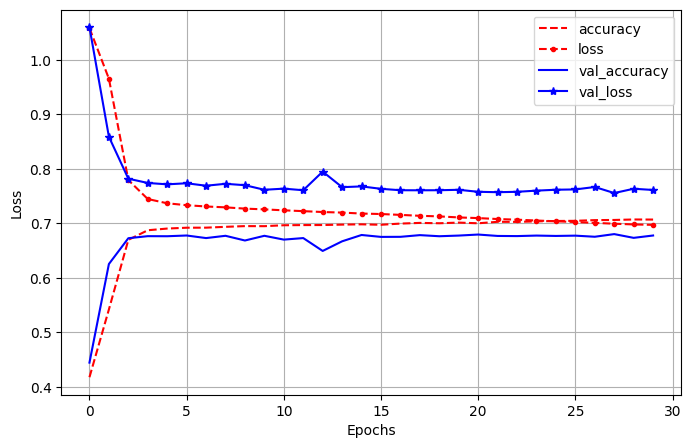

In [ ]:
# For layers 3
print(f"\nTraining model with 4 layers...")
model = varyLayers(8, 4)
history = trainModel(model, 30) # More epochs to see converge
history.nodes = 8
print("---- 4 LAYERS ---- ")
plotGraph(history)

**Observations**: For layers 1 and 2, **10 epochs** were sufficient to see a converging of the graphs into a plateau.

But for layers 3 and 4, it was observed that only 10 epochs were not sufficient. Thus, testing was done with **25 and 30 epochs** to observe a plateau.

Varying the number of layers impact how well the model can learn. **1-2 layers** allow the model to learn simple and linear patterns while **3-4 layers** can capture more complex patterns. **5+ layers** may be prone to overfitting and also require a lot more computational power.

For 4 layers we observe that:
- The accuracy obtained on the training set is 0.7.
- The accuracy obtained on the validation set is 0.68.
- The loss obtained on the training set is 0.7.
- The loss obtained on the validation set is 0.75.

**Varying layers 1-4 with 64 nodes**


Training model with 1 layer...
Epoch 1/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4339 - loss: 1.0561 - val_accuracy: 0.5678 - val_loss: 0.9632
Epoch 2/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6069 - loss: 0.9031 - val_accuracy: 0.6392 - val_loss: 0.8316
Epoch 3/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.6690 - loss: 0.7851 - val_accuracy: 0.6578 - val_loss: 0.7879
Epoch 4/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6856 - loss: 0.7502 - val_accuracy: 0.6710 - val_loss: 0.7742
Epoch 5/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6886 - loss: 0.7364 - val_accuracy: 0.6741 - val_loss: 0.7700
Epoch 6/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6935 - loss: 0.7304 - val_accuracy: 0.6705 - val_loss: 0.7721
Epoch 7/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6950 - loss: 0.7284 - val_accuracy: 0.6674 - val_loss: 0.7669
Epoch 8/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - a

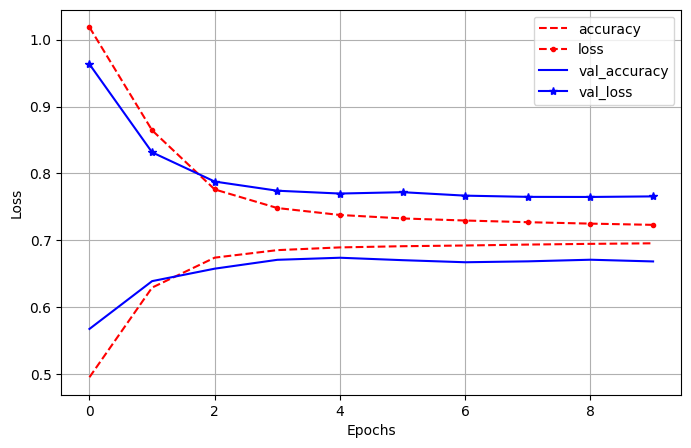

In [ ]:
# For layer 1
print(f"\nTraining model with 1 layer...")
model = varyLayers(nodes=64, layers=1)
history = trainModel(model, 10) # More epochs to see converge
history.nodes = 64
print("---- 1 LAYER ---- ")
plotGraph(history)


Training model with 2 layers...
Epoch 1/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.4298 - loss: 1.0617 - val_accuracy: 0.5286 - val_loss: 1.0110
Epoch 2/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5865 - loss: 0.9314 - val_accuracy: 0.6490 - val_loss: 0.8095
Epoch 3/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.6755 - loss: 0.7671 - val_accuracy: 0.6693 - val_loss: 0.7741
Epoch 4/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6878 - loss: 0.7383 - val_accuracy: 0.6691 - val_loss: 0.7673
Epoch 5/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6959 - loss: 0.7223 - val_accuracy: 0.6691 - val_loss: 0.7708
Epoch 6/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6967 - loss: 0.7230 - val_accuracy: 0.6751 - val_loss: 0.7670
Epoch 7/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6994 - loss: 0.7177 - val_accuracy: 0.6774 - val_loss: 0.7598
Epoch 8/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - a

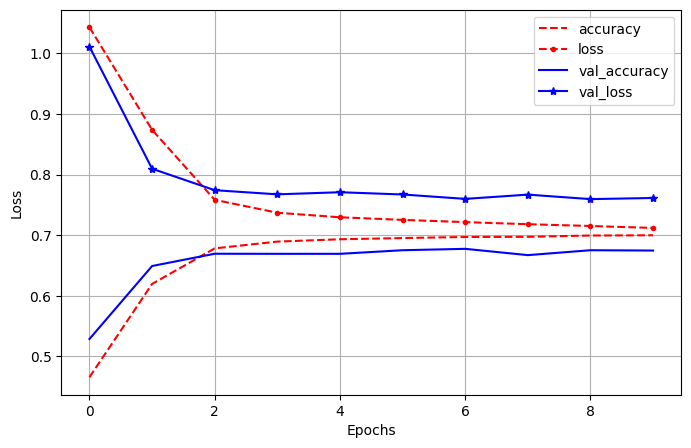

In [ ]:
# For layer 2
print(f"\nTraining model with 2 layers...")
model = varyLayers(nodes=64, layers=2)
history = trainModel(model, 10) # More epochs to see converge
history.nodes = 64
print("---- 2 LAYERS ---- ")
plotGraph(history)


Training model with 3 layers...
Epoch 1/20
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4184 - loss: 1.0637 - val_accuracy: 0.5143 - val_loss: 1.0092
Epoch 2/20
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5862 - loss: 0.9182 - val_accuracy: 0.6494 - val_loss: 0.7951
Epoch 3/20
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6766 - loss: 0.7580 - val_accuracy: 0.6748 - val_loss: 0.7706
Epoch 4/20
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6935 - loss: 0.7290 - val_accuracy: 0.6671 - val_loss: 0.7729
Epoch 5/20
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6943 - loss: 0.7233 - val_accuracy: 0.6768 - val_loss: 0.7627
Epoch 6/20
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6963 - loss: 0.7182 - val_accuracy: 0.6771 - val_loss: 0.7635
Epoch 7/20
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6992 - loss: 0.7165 - val_accuracy: 0.6751 - val_loss: 0.7631
Epoch 8/20
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - a

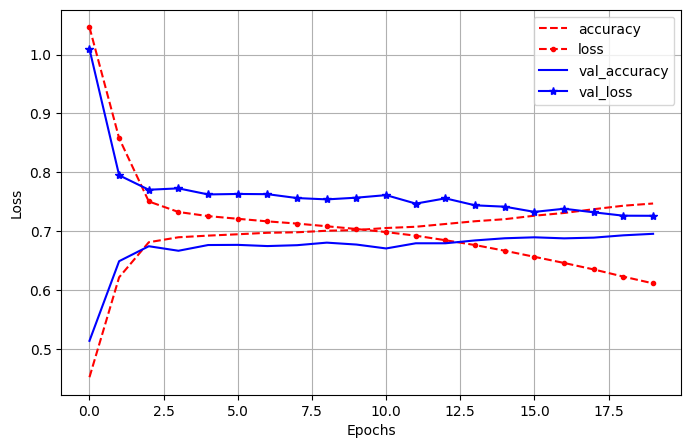

In [ ]:
# For layer 3
print(f"\nTraining model with 3 layers...")
model = varyLayers(nodes=64, layers=3)
history = trainModel(model, 20) # More epochs to see converge
history.nodes = 64
print("---- 3 LAYERS ---- ")
plotGraph(history)


Training model with 4 layers...
Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4112 - loss: 1.0665 - val_accuracy: 0.4798 - val_loss: 1.0514
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5363 - loss: 0.9860 - val_accuracy: 0.6389 - val_loss: 0.8185
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6727 - loss: 0.7690 - val_accuracy: 0.6664 - val_loss: 0.7711
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6871 - loss: 0.7346 - val_accuracy: 0.6543 - val_loss: 0.7768
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6974 - loss: 0.7196 - val_accuracy: 0.6722 - val_loss: 0.7698
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6959 - loss: 0.7175 - val_accuracy: 0.6705 - val_loss: 0.7596
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6992 - loss: 0.7134 - val_accuracy: 0.6693 - val_loss: 0.7615
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - a

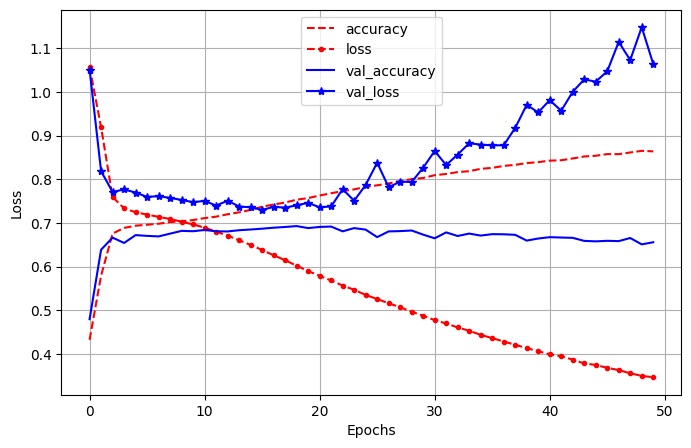

In [ ]:
# For layer 4
print(f"\nTraining model with 4 layers...")
model = varyLayers(nodes=64, layers=4)
history = trainModel(model, 50) # More epochs to see converge
history.nodes = 64
print("---- 4 LAYERS ---- ")
plotGraph(history)

**Observations**:
By varying the layers from 1 to 4 and using 64 nodes, we were able to witness more convergence before a plateau is reached, especially with 3 and 4 layers.
**Overfitting** starts to become more apparent at higher layers with a higher number of nodes.

With an epoch of 50 and for 4 layers we observe that:
- The accuracy obtained on the training set is 0.88.
- The accuracy obtained on the validation set is 0.68. (same as before)
- The loss obtained on the training set is 0.25 (very low due to overfitting)
- The loss obtained on the validation set is around 0.75 (same as before) before it starts increasing to 1.0 (overfitting).

**Conclusion**: The results for both node variations are similar if we only consider the test set. However, we can see that a higher number of layer and nodes leads to overfitting.



**Overfitting**

Select one your models that exemplifies **overfitting**.

In our experiments, we easily constructed a model achieving nearly 100% accuracy on the training data, yet showing no similar improvement on the validation set.

Present this neural network along with its accuracy and loss graphs. Explain the reasoning for concluding that the model is overfitting

The model seen just in the previous cell exemplifies overfitting. To see it achieve nearly 100% accuracy, the following hyperparemeters have been set:

- 4 Layers
- 64 nodes
- 80 training epochs

Due to a **limitation in computing power and time**, higher hyperparameters will not be used.


Training model with 4 layers...
Epoch 1/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.4068 - loss: 1.0633 - val_accuracy: 0.4637 - val_loss: 1.0409
Epoch 2/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5196 - loss: 0.9744 - val_accuracy: 0.6068 - val_loss: 0.8700
Epoch 3/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6507 - loss: 0.8049 - val_accuracy: 0.6386 - val_loss: 0.8050
Epoch 4/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6865 - loss: 0.7434 - val_accuracy: 0.6718 - val_loss: 0.7698
Epoch 5/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6991 - loss: 0.7225 - val_accuracy: 0.6708 - val_loss: 0.7631
Epoch 6/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6974 - loss: 0.7196 - val_accuracy: 0.6766 - val_loss: 0.7623
Epoch 7/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7002 - loss: 0.7156 - val_accuracy: 0.6747 - val_loss: 0.7572
Epoch 8/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - a

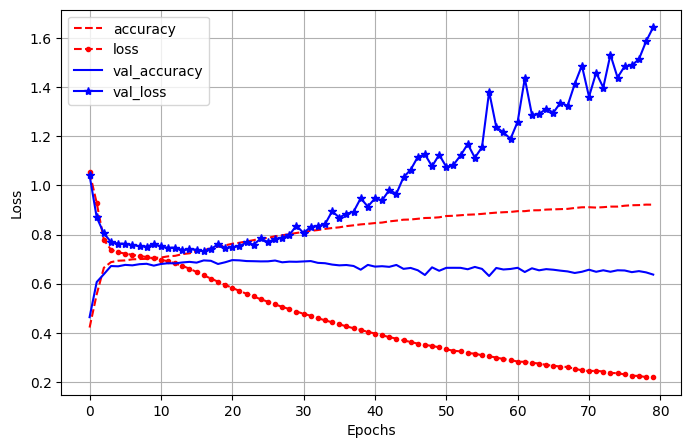

In [ ]:
print(f"\nTraining model with 4 layers...")
model = varyLayers(nodes=64, layers=4)
history = trainModel(model, 80) # 80 epochs is enough to see overfitting
history.nodes = 64
print("---- 4 LAYERS ---- ")
plotGraph(history)

**Observations**:
We can clearly see an overfitting here. More layers, nodes and epochs increase model capacity, but lead to overfitting, where the model learns noise or irrelevant patterns in the training data. The model fits to the data and not the trend in the data. This is seen in the graph as a large difference between the validation and training set metrics.

- The loss for the training set is almost to 0.
- The loss for the validation plateau-ed at around 0.75 before increasing to greater than 1.
- **The accuracy for the training set is almost at 1 (0.9)**.
- The accuracy for the validation set is plateau-ing at 0.65.


**Conclusion**:
The metrics for the validation set is almost the same as previous above experiments, showing that the model has the same performance on unseen data. This is due to overfitting.
The model should not be trained with these hyperparameters as it will do very bad on unseen data.

### Activation function



- Present results for one of the configurations mentioned above by varying the activation function. Test at least `relu` (the default) and `sigmoid`. The choice of the specific model, including the number of layers and nodes, is at your discretion. Document your observations accordingly.

We choose 2 layers, 32 nodes and 15 epochs to have a balance between a well trained model and resources available to train the model.

**Relu activation, 2 layers, 32 nodes, 15 epochs**



Training model with Relu activation, 2 Layers, 32 Nodes and 15 Epochs...
Epoch 1/15
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4391 - loss: 1.0540 - val_accuracy: 0.5690 - val_loss: 0.9458
Epoch 2/15
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6208 - loss: 0.8654 - val_accuracy: 0.6517 - val_loss: 0.8019
Epoch 3/15
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6780 - loss: 0.7582 - val_accuracy: 0.6658 - val_loss: 0.7754
Epoch 4/15
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6882 - loss: 0.7340 - val_accuracy: 0.6637 - val_loss: 0.7689
Epoch 5/15
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6921 - loss: 0.7273 - val_accuracy: 0.6716 - val_loss: 0.7609
Epoch 6/15
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6951 - loss: 0.7243 - val_accuracy: 0.6720 - val_loss: 0.7615
Epoch 7/15
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6903 - loss: 0.7260 - val_accuracy: 0.6731 - val_loss: 0.7587
Epoch 8/15
1822/

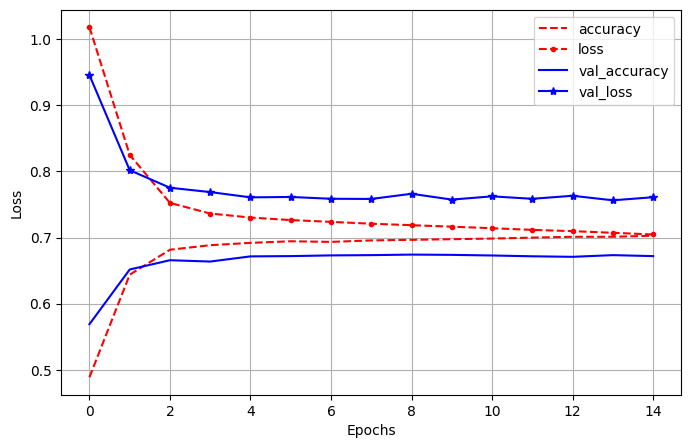

In [ ]:
print(f"\nTraining model with Relu activation, 2 Layers, 32 Nodes and 15 Epochs...")
model = varyActivation(nodes=32, layers=2, my_activation="relu")
history = trainModel(model, my_epochs=15)
history.nodes = 32
print("---- RELU ACTIVATION ---- ")
plotGraph(history)

**Sigmoid activation, 2 layers, 32 nodes, 15 epochs**



Training model with Sigmoid activation, 2 Layers, 32 Nodes and 30 Epochs...
Epoch 1/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.4057 - loss: 1.0681 - val_accuracy: 0.4200 - val_loss: 1.0789
Epoch 2/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.4154 - loss: 1.0636 - val_accuracy: 0.4436 - val_loss: 1.0795
Epoch 3/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.4172 - loss: 1.0614 - val_accuracy: 0.4303 - val_loss: 1.0738
Epoch 4/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.4209 - loss: 1.0609 - val_accuracy: 0.4645 - val_loss: 1.0764
Epoch 5/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.4332 - loss: 1.0584 - val_accuracy: 0.4229 - val_loss: 1.0681
Epoch 6/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.4337 - loss: 1.0567 - val_accuracy: 0.4303 - val_loss: 1.0663
Epoch 7/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.4681 - loss: 1.0482 - val_accuracy: 0.4896 - val_loss: 1.0579
Epoch 8/30
18

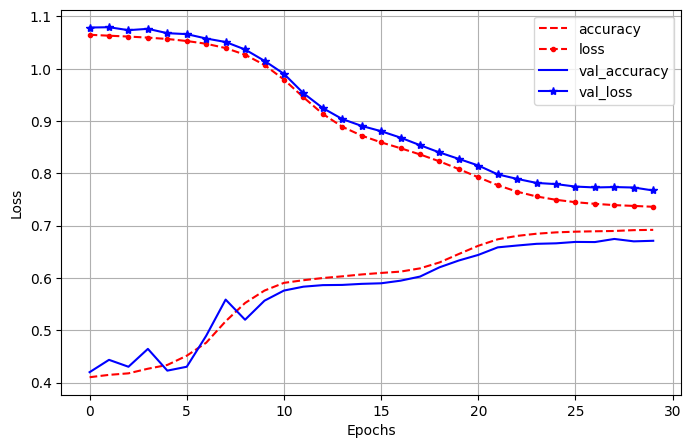

In [ ]:
print(f"\nTraining model with Sigmoid activation, 2 Layers, 32 Nodes and 30 Epochs...")
model = varyActivation(nodes=32, layers=2, my_activation="sigmoid")
history = trainModel(model, my_epochs=30)
history.nodes = 32
print("---- SIGMOID ACTIVATION ---- ")
plotGraph(history)

**Observations:**

ReLu and Sigmoid activations have a different way of converging as seen in the previous two graphs.

**ReLu:**
- Accuracy increases sharply before plateau-ing at around 0.65 to 0.7 at epoch 2.
- Loss decreases sharply from 1 to 0.75 as from epoch 2 and keeps slowly decreasing (in the case of overfitting).

**Sigmoid:**
- Accuracy gradually increases from 0 to 0.7 over all 30 epochs.
- Loss very slowly decreases from 1 to 0.75 across all 30 epochs.

Sigmoid takes more epochs to converge and plateau as compared to ReLu that converges relatively quickly.

This is because the Sigmoid activation function is prone **vanishing gradient problem.**
This causes the gradient of the sigmoid function to become near zero for very large or small inputs, leading to **very small updates to the weights** during backpropagation.

**Conclusion**:
ReLu is the preferred choice for deep networks that use hidden layers, it is faster and more effective than Sigmoid.

### Regularization

**Regularization** in neural networks is a technique used to prevent overfitting.

- One technique involves adding a penalty to the loss function to discourage excessively complex models. Apply an `l2` penalty to some or all layers. Exercise caution, as overly aggressive penalties have been problematic in our experiments. Begin with the default `l2` value of 0.01, then reduce it to 0.001 and 1e-4. Select a specific model from the above experiments and present a case where you successfully reduced overfitting. Include a pair of graphs comparing results with and without regularization. Explain your rationale to conclude that overfitting has been reduced. Do not expect to completely eliminate overfitting. Again, this is a challenging dataset to work with.

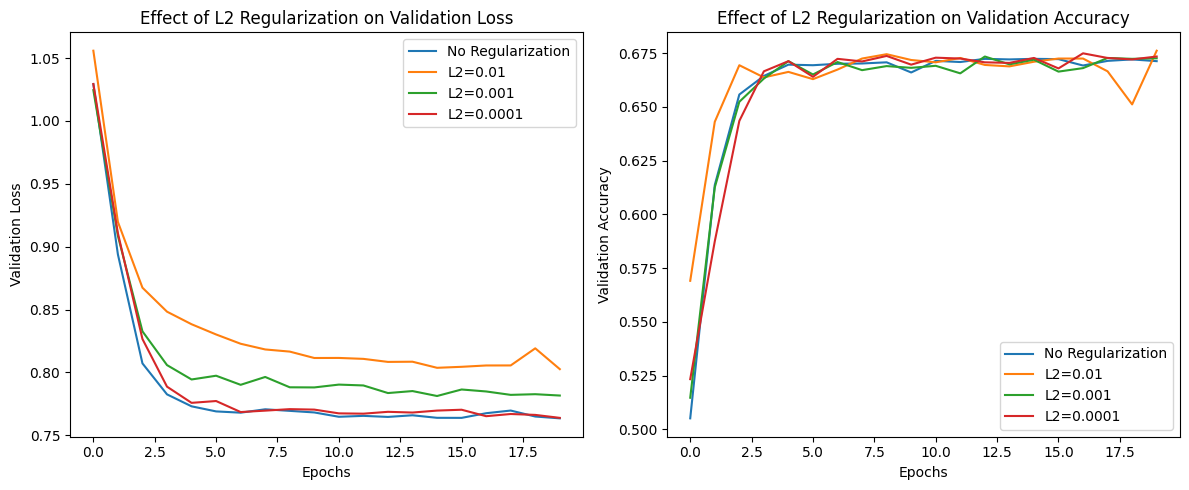

In [ ]:
# Track and plot validation loss and validation accuracy to determine the effects
# of regularization on overfitting

# Define the function to create a neural network model with regularization
def varyNode_with_regularization(node, l2_penalty=0.01):
    """
    Creates and compiles a neural network model with a custom number of hidden nodes
    and 1 hidden layer, including L2 regularization.
    """
    NN_model = tf.keras.Sequential()
    NN_model.add(tf.keras.layers.InputLayer(shape=(462,)))
    NN_model.add(tf.keras.layers.Dense(node, activation='relu',
                                       kernel_regularizer=tf.keras.regularizers.L2(l2_penalty)))
    NN_model.add(tf.keras.layers.Dense(3, activation='softmax'))

    NN_model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return NN_model

# Define L2 penalties to experiment with
l2_penalties = [0.01, 0.001, 0.0001]

# Train a baseline model without regularization for comparison
history_without_regularization = varyNode_with_regularization(node=8, l2_penalty=0).fit(
    X_train, y_train, epochs=20, validation_data=(X_valid, y_valid), verbose=0
)

# Initialize dictionary to store training histories for each regularization level
l2_histories = {'No Regularization': history_without_regularization}

# Fit models with different L2 penalties and store their histories
for l2 in l2_penalties:
    model = varyNode_with_regularization(node=8, l2_penalty=l2)
    history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid), verbose=0)
    l2_histories[f"L2={l2}"] = history

# Plot Validation Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for label, history in l2_histories.items():
    plt.plot(history.history['val_loss'], label=label)
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Effect of L2 Regularization on Validation Loss')
plt.legend()

# Plot Validation Accuracy
plt.subplot(1, 2, 2)
for label, history in l2_histories.items():
    plt.plot(history.history['val_accuracy'], label=label)
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Effect of L2 Regularization on Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

**Observations**

Above are two graphs to demonstrate the effects of `l2` regularization on model overfitting. We measure if the overfitting is being reduced or not by observing if the validation loss and accuracy decrease with regularization.

In the "Effect of L2 Regularization on Validation Loss" graph, we see that the loss is the lowest with no regularization. But as the `l2` value is present, and increases in value, the validation loss gets higher and higher. This indicates the overfitting is being reduced with the introduction of an `l2` regularization parameter.

As for the "Effect of L2 Regularization on Validation Accuracy" graph, we see that the `l2` regularization parameter has little to no effect on the accuracy of the model. This could be a positive thing, as the L2 regularization reduces validation loss, indicating a reduction of overfitting, while still maintain consistent accuracy with unseen data.

Overall, since the validation loss increases with L2 regularization, and the validation accuracy remains roughly the same, it indicates that the model does not overfit as much as having No Regularization while still performing well on unseen data.



Dropout layers are a regularization technique in neural networks where a random subset of neurons is temporarily removed during training. This helps prevent overfitting by promoting redundancy and improving the network's ability to generalize to new data. Select a specific model from the above experiments where you have muliple layers and experiment adding one or of few dropout layers into your network. Experiment with two different rates, say 0.25 and 0.5. Document your observations.

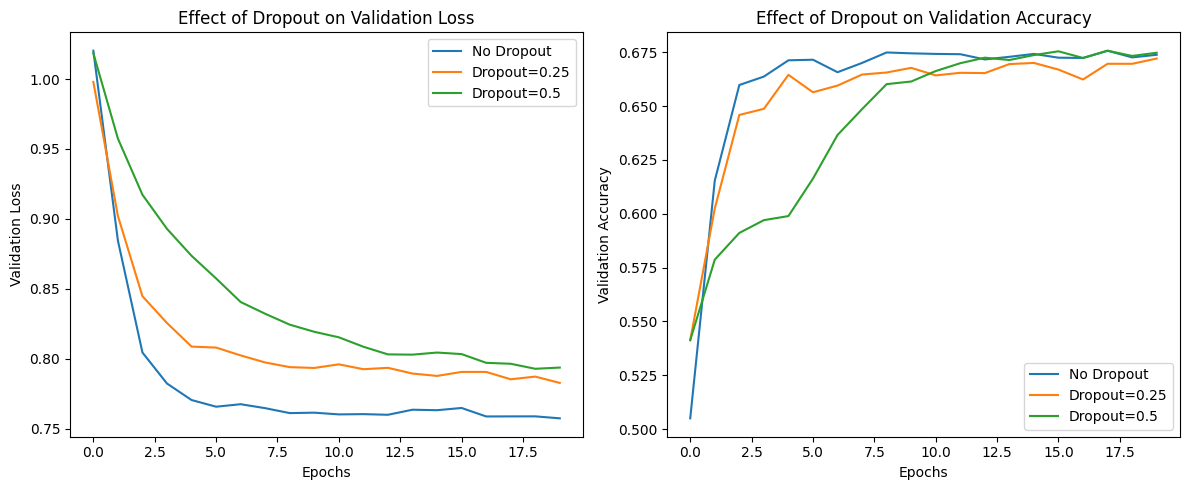

In [ ]:
# Define a function to create a model with dropout layers
def create_model_with_dropout(node, dropout_rate=0.25):
    """
    Creates and compiles a neural network model with 1 hidden layer, with dropout regularization.
    That is, 1 input layer, 1 hidden layer, 1 "dropout layer" (not a real layer, just added
    for regularization), 1 output layer.
    """
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(shape=(462,)))
    model.add(tf.keras.layers.Dense(node, activation='relu'))
    model.add(tf.keras.layers.Dropout(dropout_rate))  # Add dropout layer with specified rate
    model.add(tf.keras.layers.Dense(3, activation='softmax'))

    model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Define dropout rates to experiment with
dropout_rates = [0.25, 0.5]

# Train a baseline model without dropout for comparison
history_without_dropout = create_model_with_dropout(node=8, dropout_rate=0).fit(
    X_train, y_train, epochs=20, validation_data=(X_valid, y_valid), verbose=0
)

# Initialize dictionary to store training histories for each dropout level
dropout_histories = {'No Dropout': history_without_dropout}

# Fit models with different dropout rates and store their histories
for rate in dropout_rates:
    model = create_model_with_dropout(node=8, dropout_rate=rate)
    history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid), verbose=0)
    dropout_histories[f"Dropout={rate}"] = history

# Plot Validation Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for label, history in dropout_histories.items():
    plt.plot(history.history['val_loss'], label=label)
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Effect of Dropout on Validation Loss')
plt.legend()

# Plot Validation Accuracy
plt.subplot(1, 2, 2)
for label, history in dropout_histories.items():
    plt.plot(history.history['val_accuracy'], label=label)
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Effect of Dropout on Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

**Observations**

The graphs above demonstrate the impact of adding dropout layers with different rates (0.25 and 0.5) on validation loss and validation accuracy.

In the "Effect of Dropout on Validation Loss" graph, we see that dropout helps to reduce overfitting, as both dropout rates lead to a smoother, slightly higher validation loss but provide a more stable trend across epochs, especially with the higher dropout rate of 0.5. This suggests that dropout effectively prevents the model from fitting too closely to the training data, resulting in better generalization.

For the "Effect of Dropout on Validation Accuracy" graph, both dropout rates produce comparable accuracy to the model without dropout. The slight fluctuation in accuracy suggests that dropout introduces some regularization without significantly impacting the model's ability to achieve high accuracy.

Summarize your experiments with using a graphical representation such as Figure 6.15 [on this page](https://egallic.fr/Enseignement/ML/ECB/book/deep-learning.html).

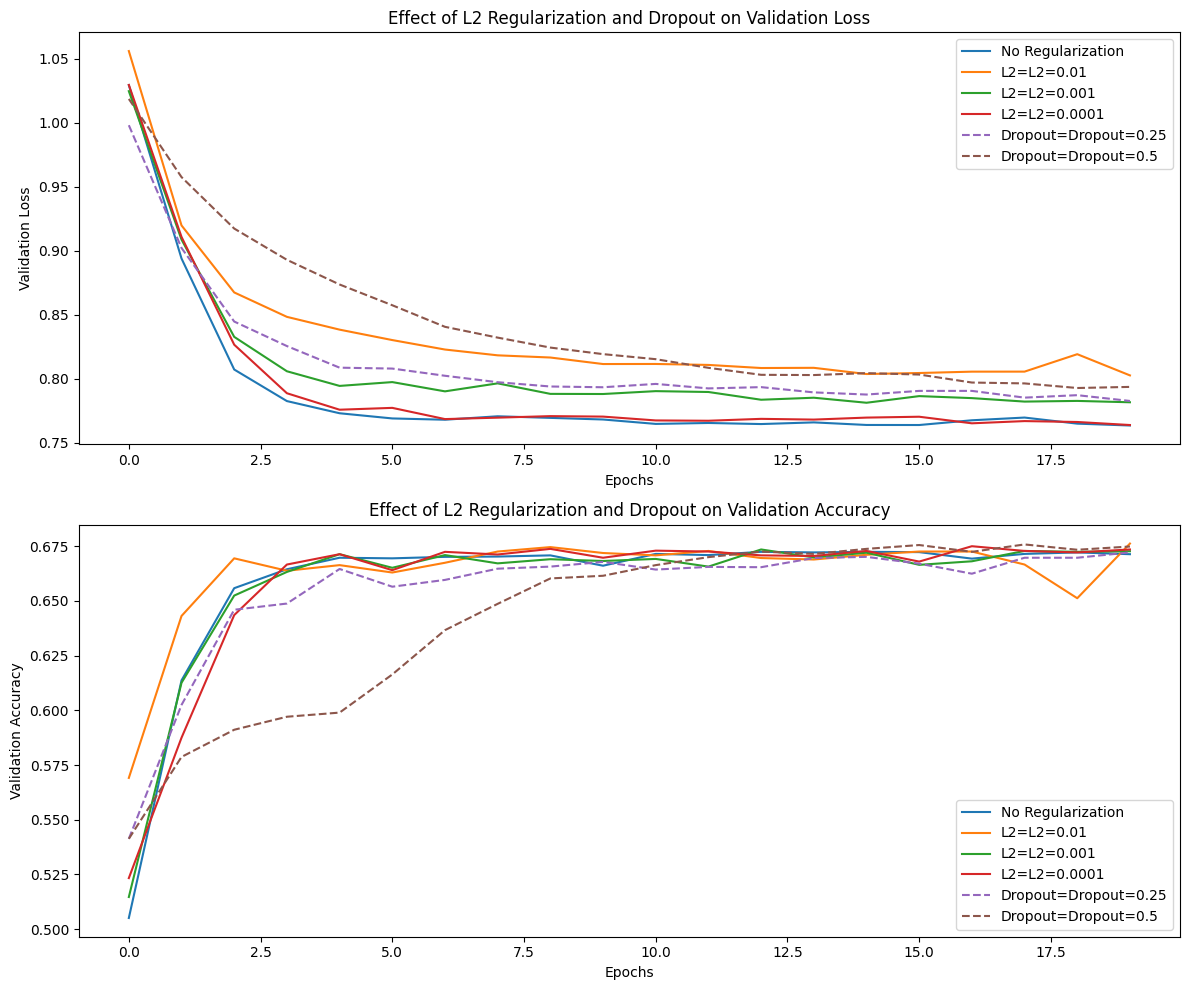

In [ ]:
# Combined Plot for Validation Loss and Validation Accuracy for L2 and Dropout

plt.figure(figsize=(12, 10))

# Plot Validation Loss for both L2 and Dropout experiments
plt.subplot(2, 1, 1)
for label, history in l2_histories.items():
    # Only add "No Regularization" label once from l2_histories
    if label == "No Regularization":
        plt.plot(history.history['val_loss'], label=f"{label}")
    else:
        plt.plot(history.history['val_loss'], label=f"L2={label}")
for label, history in dropout_histories.items():
    if label != "No Dropout":  # Skip "No Dropout" to avoid redundancy
        plt.plot(history.history['val_loss'], linestyle='--', label=f"Dropout={label}")
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Effect of L2 Regularization and Dropout on Validation Loss')
plt.legend()

# Plot Validation Accuracy for both L2 and Dropout experiments
plt.subplot(2, 1, 2)
for label, history in l2_histories.items():
    if label == "No Regularization":
        plt.plot(history.history['val_accuracy'], label=f"{label}")
    else:
        plt.plot(history.history['val_accuracy'], label=f"L2={label}")
for label, history in dropout_histories.items():
    if label != "No Dropout":  # Skip "No Dropout" to avoid redundancy
        plt.plot(history.history['val_accuracy'], linestyle='--', label=f"Dropout={label}")
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Effect of L2 Regularization and Dropout on Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


**Observations and Conclusion**

Overall, with the summarized plots of No Regularization vs. "L2 Regularization" vs. "Dropout Regularization", we can conclude that the presence of Regularization reduces model overfitting while still performing with a consistent level of accuracy.

Early stopping is a regularization technique in neural network training wherein the process is halted when validation set performance starts to decline, thus preventing overfitting by avoiding the learning of noise in the training data. From all the experiments conducted thus far, choose **one** configuration (the number of layers, number of nodes, activation function, L2 penalty, and dropout layers) that yielded the best performance. Use a graph of loss and accuracy to determine the optimal number of training iterations for this network. What is the optimal number of epochs for this network configuration and why?

In [ ]:
# Define the chosen configuration for the neural network model
def best_model_with_early_stopping():
    """
    Creates and compiles a neural network model with the chosen best configuration.
    1 input layer, 1 hidden layer, 1 "dropout layer", 1 output layer.
    NOTE: The dropout layer is not a "real" layer. It is just for regularization
    to reduce model overfitting.
    """
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(shape=(462,)))  # Input layer with 462 features
    model.add(tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)))  # hidden layer with 32 nodes, ReLU activation, and L2 regularization with 0.001
    model.add(tf.keras.layers.Dropout(0.25))  # Dropout layer with 0.25 rate
    model.add(tf.keras.layers.Dense(3, activation='softmax'))  # Output layer with 3 nodes for classification

    model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

Chosen Configuration:
Number of Hidden Layers: 1
Number of Nodes in Hidden Layer: 32
Activation Function: ReLU in hidden layer, Softmax in output layer
L2 Penalty: 0.001
Dropout Rate: 0.25
Epoch 1/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4539 - loss: 1.1037 - val_accuracy: 0.5788 - val_loss: 1.0054
Epoch 2/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5877 - loss: 0.9665 - val_accuracy: 0.6451 - val_loss: 0.8968
Epoch 3/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6388 - loss: 0.8894 - val_accuracy: 0.6617 - val_loss: 0.8549
Epoch 4/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6582 - loss: 0.8515 - val_accuracy: 0.6709 - val_loss: 0.8371
Epoch 5/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6751 - loss: 0.8219 - val_accuracy: 0.6739 - val_loss: 0.8268
Epoch 6/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6761 - loss: 0.8121 - val_accuracy: 0.6713 - val_loss: 0.8210
Epoch 7/80
1822/1822 ━━━━━━━━━━

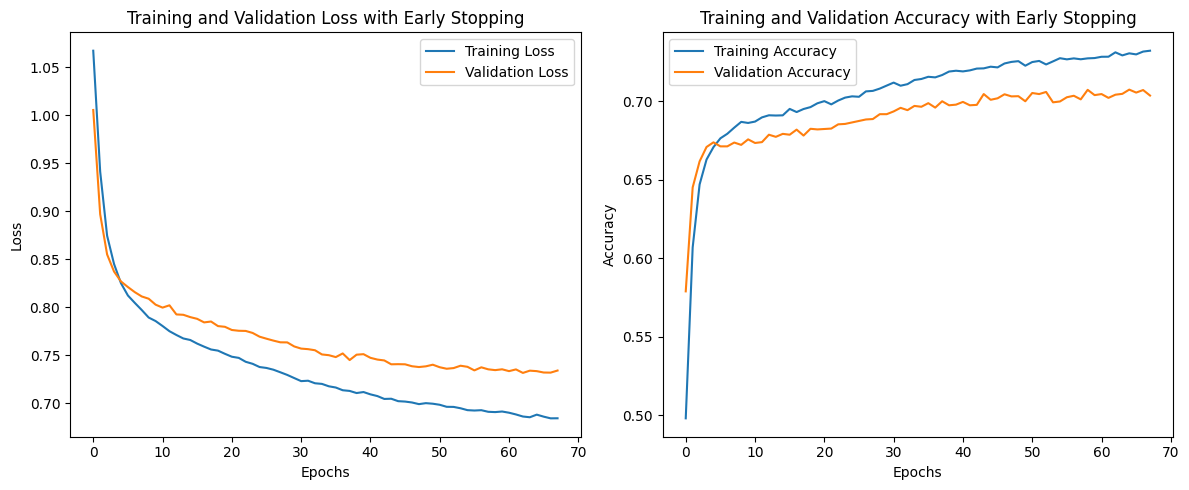

The optimal number of epochs with early stopping is: 68


In [ ]:
# Print the chosen configuration
print("Chosen Configuration:")
print("Number of Hidden Layers: 1")
print("Number of Nodes in Hidden Layer: 32")  # previously concluded that 32 nodes was best
print("Activation Function: ReLU in hidden layer, Softmax in output layer")
print("L2 Penalty: 0.001")
print("Dropout Rate: 0.25")

# Initialize the early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with early stopping
best_nn_model = best_model_with_early_stopping()
history = best_nn_model.fit(
    X_train, y_train,
    epochs=80,  # Train for a large number of epochs, early stopping will handle when to stop
    validation_data=(X_valid, y_valid),
    callbacks=[early_stopping],
    verbose=1
)

# Plot the training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss with Early Stopping')
plt.legend()

# Plot the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy with Early Stopping')
plt.legend()

plt.tight_layout()
plt.show()

# Print the optimal number of epochs
optimal_epochs = len(history.history['val_loss'])
print(f"The optimal number of epochs with early stopping is: {optimal_epochs}")

**Explanation and Observations**

The chosen configuration has been printed with details including the number of layers, the number of nodes in the hidden layer, the activation functions, the L2 penalty, and the dropout rate. This configuration was selected based on prior experiments as it provided a good balance of validation accuracy and loss reduction.

In this training session, early stopping halted the training process after 68 epochs, as the validation loss stopped improving. The graphs of loss and accuracy reveal that, beyond this point, the model did not gain any significant improvement, thus preventing overfitting. The optimal number of epochs for this configuration is 68, as this is where the validation loss stabilized, indicating a balanced model that generalizes well without overfitting.

## Test



9. **Model Comparison**:

- Evaluate the baseline model on the test set, using the optimal parameter set identified through grid search. Additionally, apply your best-performing neural network configuration to the test set.

- Quantify the performance of the baseline model (best hyperparameter configuration) and your neural network (best configuration) using precision, recall, and F1-score as metrics. How do these two models compare to the dummy model?

- Provide recommendations on which model(s) to choose for this task and justify your choices based on the analysis results.

**Testing the NN model**

Our best neural network model configuration is:
```
- 32 nodes
- 1 hidden layer
- 68 epochs
- ReLU activation in hidden layer, Softmax activation in output layer
- L2 regularization with 0.001
- Dropout layer with 25% neuron drop
- Early stopping
- SGD optimizer
```

In [ ]:
## Generate predictions on test set
y_pred_probs = best_nn_model.predict(X_test)
y_pred_classes = y_pred_probs.argmax(axis=1)  # convert probabilities to class predictions

# Print classification report
print("Classification Report for the Chosen Neural Network Configuration:")
print(classification_report(y_test, y_pred_classes, target_names=["Class 0", "Class 1", "Class 2"]))


233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Classification Report for the Chosen Neural Network Configuration:
              precision    recall  f1-score   support

     Class 0       0.80      0.80      0.80      2528
     Class 1       0.73      0.60      0.66      1852
     Class 2       0.71      0.79      0.75      3051

    accuracy                           0.75      7431
   macro avg       0.75      0.73      0.74      7431
weighted avg       0.75      0.75      0.74      7431



**Analysis**

Observing the classification report above, we conclude that the macro average of this neural network model is:
- Precision: 0.75
- Recall: 0.73
- F1 score: 0.74

We can observe that the macro F1, precision and recall are much higher than the dummy and baseline models. Note that macro is used here as this is a multiclass classification problem.

**Scaled vs Unscaled Data**

In reference to **step 3**, we will now test the performace of scaled vs unscaled data on our predictions

In [ ]:
# create the best model
model = best_model_with_early_stopping()

# Initialize the early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# ----- USE SCALED DATA -----

# Train the model with early stopping
model.fit(
    X_train_scaled, y_train,
    epochs=80,  # Train for a large number of epochs, early stopping will handle when to stop
    validation_data=(X_valid_scaled, y_valid),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4310 - loss: 1.1155 - val_accuracy: 0.5559 - val_loss: 1.0430
Epoch 2/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5706 - loss: 1.0006 - val_accuracy: 0.6323 - val_loss: 0.9178
Epoch 3/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6324 - loss: 0.8990 - val_accuracy: 0.6473 - val_loss: 0.8622
Epoch 4/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6560 - loss: 0.8496 - val_accuracy: 0.6700 - val_loss: 0.8359
Epoch 5/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6698 - loss: 0.8254 - val_accuracy: 0.6709 - val_loss: 0.8253
Epoch 6/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6757 - loss: 0.8173 - val_accuracy: 0.6732 - val_loss: 0.8175
Epoch 7/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6755 - loss: 0.8090 - val_accuracy: 0.6751 - val_loss: 0.8117
Epoch 8/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6814 - loss: 0.7960 - 

In [ ]:
## Generate predictions on test set
y_pred_probs = model.predict(X_test_scaled)
y_pred_classes = y_pred_probs.argmax(axis=1)  # convert probabilities to class predictions

# Print classification report
print("Classification Report for the Chosen Neural Network Configuration:")
print(classification_report(y_test, y_pred_classes, target_names=["Class 0", "Class 1", "Class 2"]))

233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Classification Report for the Chosen Neural Network Configuration:
              precision    recall  f1-score   support

     Class 0       0.80      0.79      0.80      2528
     Class 1       0.72      0.61      0.66      1852
     Class 2       0.71      0.78      0.74      3051

    accuracy                           0.74      7431
   macro avg       0.74      0.73      0.73      7431
weighted avg       0.74      0.74      0.74      7431



**Analysis of using Scaled vs Unscaled data**

Observing the classification report above, we conclude that the macro average of this neural network model on **SCALED** data is:
- Precision: 0.74
- Recall: 0.73
- F1 score: 0.73

We notice some minor differences between the model that was trained with unscaled vs. scaled data, all of which are negligible.

*NOTE: Recall that the model trained on unscaled data was as follows:*
- Precision: 0.75
- Recall: 0.73
- F1 score: 0.74

This is a very slight difference and may not even be due to the fact that we scaled the data. However it is still worth noting that scaling the data in this case might affect the performace due to information loss by introducing small changes in the feature distribution.


Quantify the performance of the Dummy Classifier model.

In [ ]:
# Use the dummy classifier to make predictions
dummy_predictions = dummy_clf.predict(X_test)

# Generate the classification report for the dummy classifier
dummy_report = classification_report(y_test, dummy_predictions, target_names=['Class 0', 'Class 1', 'Class 2'], zero_division=0)
print("Classification Report for Dummy Classifier:")
print(dummy_report)

Classification Report for Dummy Classifier:
              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00      2528
     Class 1       0.00      0.00      0.00      1852
     Class 2       0.41      1.00      0.58      3051

    accuracy                           0.41      7431
   macro avg       0.14      0.33      0.19      7431
weighted avg       0.17      0.41      0.24      7431



The Dummy Classifier performs with the following metrics
```
Precision : 0.14
Recall    : 0.33
F1 score  : 0.19
```
Recall that we determined that the optimal parameter set identified through grid search for Decision Tree is
```
Best parameters for Decision Tree: {'criterion': 'entropy', 'max_depth': 9}

- Precision : 0.544542
- Recall    : 0.519728
- F1 score  : 0.5195560009153531
```

Recall that the best-performing neural network configuration that we have determined is
```
Number of Hidden Layers: 1
Number of Nodes in Hidden Layer: 32
Activation Function: ReLU in hidden layer, Softmax in output layer
L2 Penalty: 0.001
Dropout Rate: 0.25
Epochs: 68
Optimizer: SGD
With early stopping

- Precision : 0.75
- Recall    : 0.73
- F1 score  : 0.74
```

**Analysis**

We see that overall, when measured by their F1 scores, the Dummy Classifier performs the worst, followed by the Decision Tree, and the **Neural Network performs the best** with high metrics of around 0.75 precision, recall and F1 scores.

To prevent overfitting and achieve an optimum model, we determined that 32 neurons and one hidden layer was sufficient. 68 epochs made sure the model learned the complex protein patterns of our dataset. To further prevent overfitting, a penalty was added to the loss functions when doing backpropagation. Additionally, neurons are dropped at a rate of 25% to ensure that the network does not depend entirely on a set of neurons. Lastly, early stopping will stop the training when the best accuracy has been reached.

The decision tree has a lower score as it is unable to learn the complex patterns in the protein structure with simple rules and boundaries. However, the decision tree does not perform as badly as the dummy classifier as the dummy classifier's basic methodology allows it to achieve a decent recall simply by predicting the most frequent class.



**Recommendation for which model to use for this task**

Based on the best configurations that we have chosen for each of our models, as well as the performance metrics that we have calculated, we recommend the **Neural Network Model**.

The DT model showed the second highest precision, recall, and F1 score compared to the dummy classifier.

The neural network is much more sophisticated, can capture complex protein patterns and has several techniques to prevent overfitting so that the model can learn the patterns without learning the dataset itself. Due to the large compexity of the protein structure dataset, the neural network is more suited for this task.

However, the DT model is also more interpretable and faster compared to the neural network, making it easier to understand and potentially justify decisions. On the contrary, the neural network operates as a "black box" with lower transparency in its decision-making process. So, the DT model may be a good **second choice** for this task.

Overall, we recommend the Neural Network for this task due to its better performance and metrics for the complex protein structure prediction task.

# Resources

**Online sources:**
- https://towardsdatascience.com/dummy-classifier-explained-a-visual-guide-with-code-examples-for-beginners-009ff95fc86e
- https://datascience.stackexchange.com/questions/6048/should-i-use-a-decision-tree-or-logistic-regression-for-classification
- https://www.youtube.com/watch?v=CqOfi41LfDw
- https://itsudit.medium.com/regularization-taming-the-wild-l1-and-l2-beasts-and-the-mysterious-dropout-a2b81ee255ba
- https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping
- https://dev.to/amananandrai/10-famous-machine-learning-optimizers-1e22
- https://egallic.fr/Enseignement/ML/ECB/book/deep-learning.html

**Course notes:**
- https://turcotte.xyz/teaching/csi-4106/lectures/09/slides.html

**Previous work:**
- CSI4106 Assignment 2 https://colab.research.google.com/drive/1iYHcljtoYztI8jCNl1iOtmzwrB2yPl01?usp=sharing

**ChatGPT Transcript**
- https://chatgpt.com/share/672fdcd7-9954-8001-a122-79a51f8d5727

NOTE: This notebook can also be accessed via the following Google Colab URL
- https://colab.research.google.com/drive/1v3-kykxhPXH6E_Z0klQhTdFd_Ll0J5tq?usp=sharing

**Division of tasks:**
- Kanjanokphat: Section 1-5
- Kien: Section 6-7, 9
- Both: Section 8, Verification & Validation

The tasks were split equally between the 2 students and then both students went on a meeting to verify and finalize the work.

We both went through the whole assignment together at the end to make sure we understand the use of functions and concepts applied, resolving any disagreements and suggesting enhancements. This way, both students achieved the learning outcomes.
